# CanAI Cafe - EDA & Business Insights
**Owner:** Nikhil Khatri  
**Input:** `../data/clean/data_clean.csv`  
**Output:** charts saved to `../outputs/charts/`

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
CHARTS_DIR = '../outputs/charts/'
os.makedirs(CHARTS_DIR, exist_ok=True)

## 1. Load Clean Data

In [8]:
df = pd.read_csv('../data/clean/data_clean.csv', parse_dates=['Transaction Date'])
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Shape: 9483 rows, 10 columns


,Row_ID,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Province
0,1,TXN_9687814,Coffee,2,3.5,7.0,Digital Wallet,In-store,2023-09-28,British Columbia
1,2,TXN_7002925,Refresher,2,5.0,10.0,Cash,Unknown,2023-05-02,Newfoundland and Labrador
2,3,TXN_7668262,Donut,1,2.0,2.0,Digital Wallet,In-store,2023-11-27,British Columbia
3,4,TXN_9390285,Coffee,1,3.5,3.5,Unknown,Takeaway,2023-05-11,Newfoundland and Labrador
4,5,TXN_7321503,Tea,1,3.0,3.0,Credit Card,Takeaway,2023-09-15,British Columbia


### 1.1 Data Types

In [9]:
df.dtypes

Row_ID                       int64
Transaction ID              object
Item                        object
Quantity                     int64
Price Per Unit             float64
Total Spent                float64
Payment Method              object
Location                    object
Transaction Date    datetime64[ns]
Province                    object
dtype: object

### 1.2 Nulls & "Unknown" Values

In [10]:
print("Null counts per column:")
print(df.isnull().sum())
print(f"\n'Unknown' counts per column:")
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'Unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(df) * 100
        print(f"  {col}: {unknown_count} ({pct:.1f}%)")

Null counts per column:
Row_ID              0
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Province            0
dtype: int64

'Unknown' counts per column:
  Payment Method: 524 (5.5%)
  Location: 832 (8.8%)
  Province: 396 (4.2%)


### 1.3 Summary Statistics

In [11]:
print(f"Total revenue: ${df['Total Spent'].sum():,.2f}")
print(f"Records: {len(df):,}")
print(f"Date range: {df['Transaction Date'].min().date()} to {df['Transaction Date'].max().date()}")
print(f"\nUnique values:")
print(f"  Items: {df['Item'].nunique()} - {sorted(df['Item'].unique())}")
print(f"  Locations: {df['Location'].nunique()} - {sorted(df['Location'].unique())}")
print(f"  Provinces: {df['Province'].nunique()} - {sorted(df['Province'].unique())}")
print(f"  Payment Methods: {df['Payment Method'].nunique()} - {sorted(df['Payment Method'].unique())}")

Total revenue: $81,932.50
Records: 9,483
Date range: 2023-01-01 to 2023-12-31

Unique values:
  Items: 8 - ['Coffee', 'Cookie', 'Donut', 'Juice', 'Refresher', 'Salad', 'Sandwich', 'Tea']
  Locations: 3 - ['In-store', 'Takeaway', 'Unknown']
  Provinces: 6 - ['British Columbia', 'Manitoba', 'Newfoundland and Labrador', 'Ontario', 'Saskatchewan', 'Unknown']
  Payment Methods: 4 - ['Cash', 'Credit Card', 'Digital Wallet', 'Unknown']


In [12]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,9483.000000,9483.000000,9483.000000
mean,1.988506,4.342929,8.639935
std,1.086326,2.199662,6.893396
min,1.000000,2.000000,2.000000
25%,1.000000,3.000000,3.500000
50%,2.000000,3.500000,7.000000
75%,3.000000,5.000000,10.500000
max,5.000000,9.000000,45.000000


## 2. Sales Trends Over Time

Aggregate revenue and transaction volume at daily, weekly, and monthly grains. Identify trends, seasonality, and anomalies.

### 2.1 Monthly Revenue & Transaction Volume

In [ ]:
monthly = df.set_index('Transaction Date').resample('MS').agg(
    revenue=('Total Spent', 'sum'),
    transactions=('Transaction ID', 'count'),
    units=('Quantity', 'sum')
).reset_index()
monthly['month_label'] = monthly['Transaction Date'].dt.strftime('%b %Y')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly['Transaction Date'], monthly['revenue'], width=20, alpha=0.6, color='steelblue', label='Revenue')
ax1.set_ylabel('Revenue ($)', color='steelblue')
ax1.set_xlabel('Month')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly['Transaction Date'], monthly['transactions'], color='coral', marker='o', linewidth=2, label='Transactions')
ax2.set_ylabel('Transaction Count', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_title('Monthly Revenue & Transaction Volume')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}monthly_revenue_transactions.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly[['month_label', 'revenue', 'transactions', 'units']].to_string(index=False))

### 2.2 Month-over-Month Growth Rates

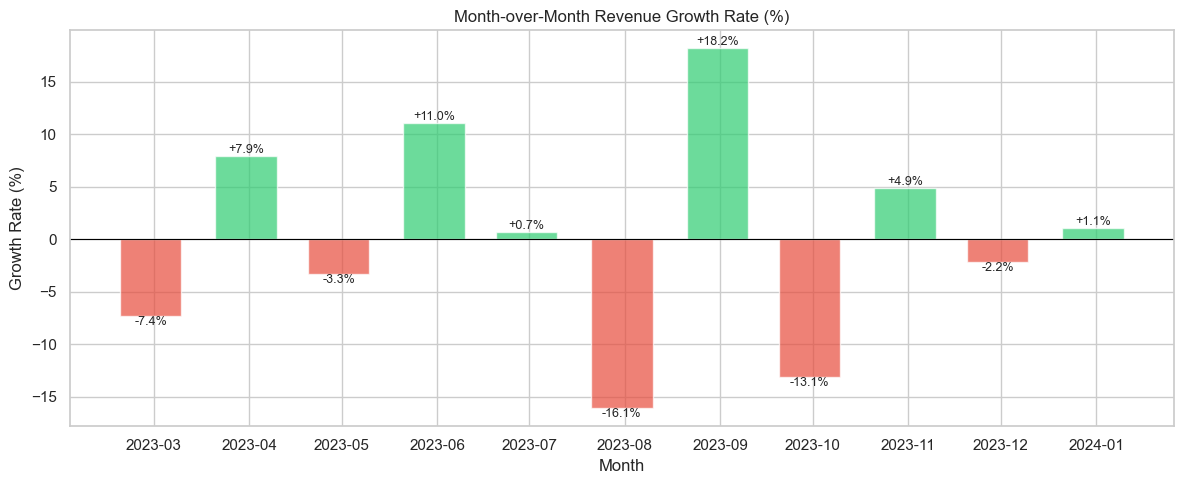

month_label  revenue_growth  txn_growth
   Jan 2023             NaN         NaN
   Feb 2023       -7.350069   -9.257004
   Mar 2023        7.933162    8.724832
   Apr 2023       -3.291615   -8.148148
   May 2023       11.018851    8.064516
   Jun 2023        0.667071    3.233831
   Jul 2023      -16.091031  -12.650602
   Aug 2023       18.163689   16.413793
   Sep 2023      -13.116857  -10.900474
   Oct 2023        4.856255    9.308511
   Nov 2023       -2.178585   -3.284672
   Dec 2023        1.113552   -0.503145


In [14]:
monthly['revenue_growth'] = monthly['revenue'].pct_change() * 100
monthly['txn_growth'] = monthly['transactions'].pct_change() * 100

fig, ax = plt.subplots(figsize=(12, 5))
growth = monthly.iloc[1:]
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in growth['revenue_growth']]
ax.bar(growth['Transaction Date'], growth['revenue_growth'], width=20, color=colors, alpha=0.7)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Month-over-Month Revenue Growth Rate (%)')
ax.set_xlabel('Month')
ax.set_ylabel('Growth Rate (%)')

for i, row in growth.iterrows():
    ax.annotate(f"{row['revenue_growth']:+.1f}%",
                xy=(row['Transaction Date'], row['revenue_growth']),
                ha='center', va='bottom' if row['revenue_growth'] >= 0 else 'top',
                fontsize=9)

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}mom_revenue_growth.png', dpi=150, bbox_inches='tight')
plt.show()

print(monthly[['month_label', 'revenue_growth', 'txn_growth']].to_string(index=False))

### 2.3 Weekly Revenue Trend

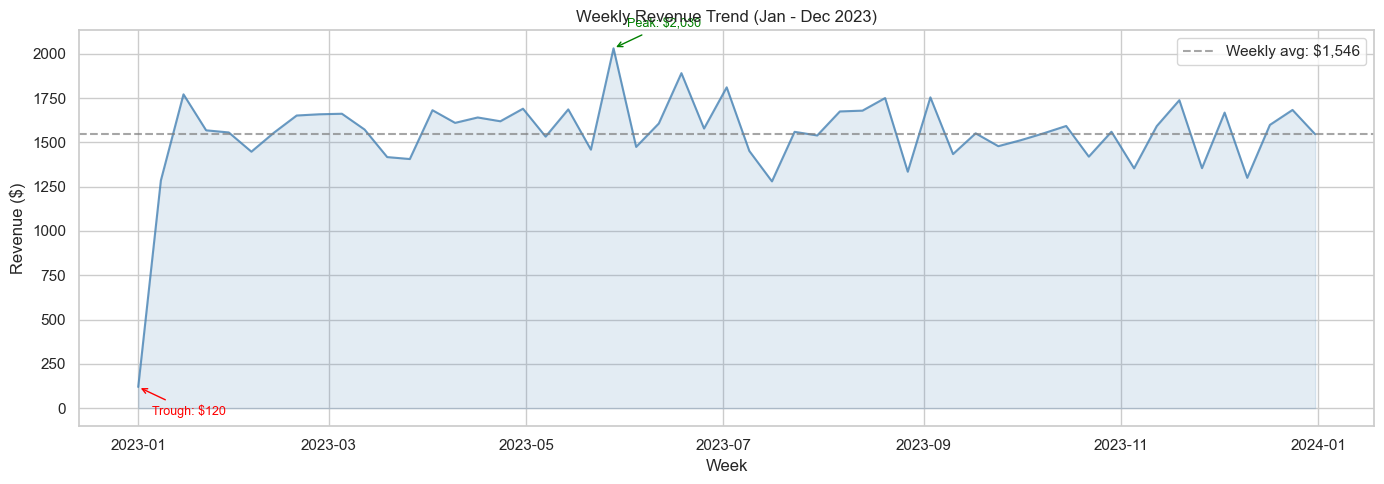

In [15]:
weekly = df.set_index('Transaction Date').resample('W').agg(
    revenue=('Total Spent', 'sum'),
    transactions=('Transaction ID', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly['Transaction Date'], weekly['revenue'], color='steelblue', linewidth=1.5, alpha=0.8)
ax.fill_between(weekly['Transaction Date'], weekly['revenue'], alpha=0.15, color='steelblue')

mean_rev = weekly['revenue'].mean()
ax.axhline(y=mean_rev, color='gray', linestyle='--', alpha=0.7, label=f'Weekly avg: ${mean_rev:,.0f}')

peak_idx = weekly['revenue'].idxmax()
trough_idx = weekly['revenue'].idxmin()
ax.annotate(f"Peak: ${weekly.loc[peak_idx, 'revenue']:,.0f}",
            xy=(weekly.loc[peak_idx, 'Transaction Date'], weekly.loc[peak_idx, 'revenue']),
            xytext=(10, 15), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='green'), color='green')
ax.annotate(f"Trough: ${weekly.loc[trough_idx, 'revenue']:,.0f}",
            xy=(weekly.loc[trough_idx, 'Transaction Date'], weekly.loc[trough_idx, 'revenue']),
            xytext=(10, -20), textcoords='offset points', fontsize=9,
            arrowprops=dict(arrowstyle='->', color='red'), color='red')

ax.set_title('Weekly Revenue Trend (Jan - Dec 2023)')
ax.set_xlabel('Week')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Daily Revenue Trend

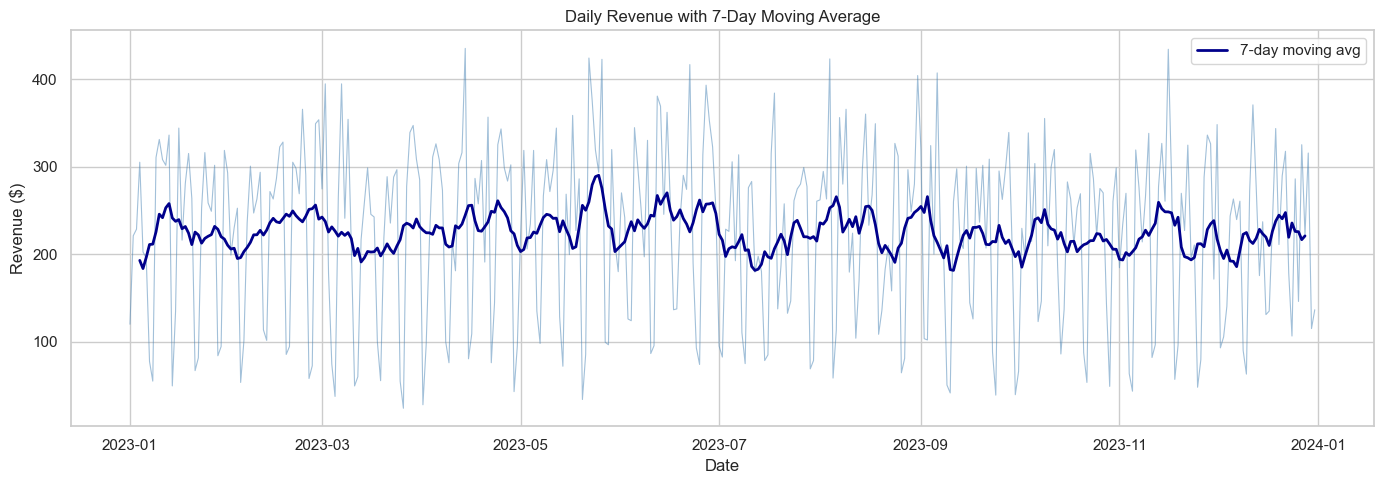

In [16]:
daily = df.set_index('Transaction Date').resample('D').agg(
    revenue=('Total Spent', 'sum'),
    transactions=('Transaction ID', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily['Transaction Date'], daily['revenue'], color='steelblue', linewidth=0.8, alpha=0.5)
daily['revenue_7d'] = daily['revenue'].rolling(7, center=True).mean()
ax.plot(daily['Transaction Date'], daily['revenue_7d'], color='darkblue', linewidth=2, label='7-day moving avg')
ax.set_title('Daily Revenue with 7-Day Moving Average')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue ($)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}daily_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Day-of-Week Patterns

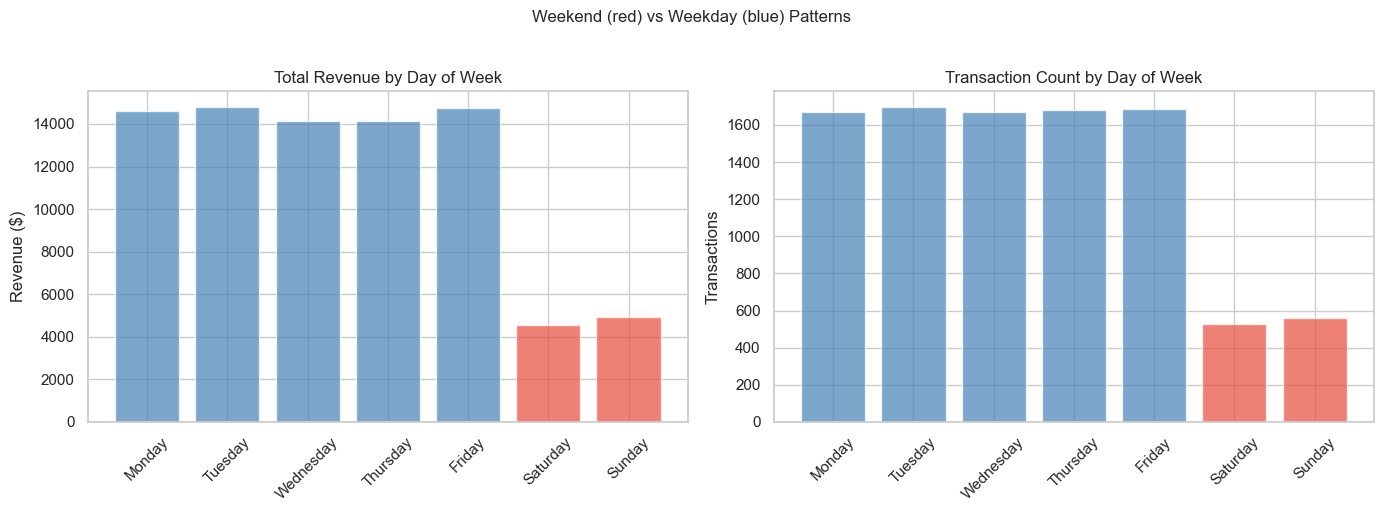

Weekend vs Weekday comparison:
         total_revenue  avg_transaction  count
Weekday        72428.0         8.623408   8399
Weekend         9504.5         8.767989   1084


In [17]:
df['day_of_week'] = df['Transaction Date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow = df.groupby('day_of_week').agg(
    total_revenue=('Total Spent', 'sum'),
    avg_daily_revenue=('Total Spent', 'mean'),
    transactions=('Transaction ID', 'count')
).reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in day_order]
axes[0].bar(dow.index, dow['total_revenue'], color=colors, alpha=0.7)
axes[0].set_title('Total Revenue by Day of Week')
axes[0].set_ylabel('Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dow.index, dow['transactions'], color=colors, alpha=0.7)
axes[1].set_title('Transaction Count by Day of Week')
axes[1].set_ylabel('Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Weekend (red) vs Weekday (blue) Patterns', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}day_of_week_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday'])
weekend_summary = df.groupby('is_weekend').agg(
    total_revenue=('Total Spent', 'sum'),
    avg_transaction=('Total Spent', 'mean'),
    count=('Transaction ID', 'count')
)
weekend_summary.index = ['Weekday', 'Weekend']
print('Weekend vs Weekday comparison:')
print(weekend_summary.to_string())

### 2.6 Monthly Seasonality & Quarterly Breakdown

In [ ]:
monthly['quarter'] = monthly['Transaction Date'].dt.quarter
quarterly = monthly.groupby('quarter')['revenue'].sum().reset_index()
quarterly.columns = ['Quarter', 'Revenue']
quarterly['Share'] = (quarterly['Revenue'] / quarterly['Revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

month_names = monthly['Transaction Date'].dt.strftime('%b')
q_colors = {1: '#3498db', 2: '#2ecc71', 3: '#e67e22', 4: '#e74c3c'}
bar_colors = [q_colors[q] for q in monthly['quarter']]
axes[0].bar(month_names, monthly['revenue'], color=bar_colors, alpha=0.7)
axes[0].set_title('Monthly Revenue (colored by quarter)')
axes[0].set_ylabel('Revenue ($)')
axes[0].axhline(y=monthly['revenue'].mean(), color='gray', linestyle='--', alpha=0.7, label=f"Avg: ${monthly['revenue'].mean():,.0f}")
axes[0].legend()

axes[1].pie(quarterly['Revenue'], labels=[f"Q{q}\n${r:,.0f}\n({s}%)" for q, r, s in zip(quarterly['Quarter'], quarterly['Revenue'], quarterly['Share'])],
            colors=[q_colors[q] for q in quarterly['Quarter']], autopct='', startangle=90)
axes[1].set_title('Revenue Share by Quarter')

plt.tight_layout()
plt.savefig(f'{CHARTS_DIR}monthly_seasonality_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

print('Quarterly revenue breakdown:')
print(quarterly.to_string(index=False))

In [ ]:
strongest = monthly.loc[monthly['revenue'].idxmax()]
weakest = monthly.loc[monthly['revenue'].idxmin()]
weekend_pct = weekend_summary.loc['Weekend', 'count'] / len(df) * 100
weekday_pct = 100 - weekend_pct
q_min, q_max = quarterly['Share'].min(), quarterly['Share'].max()

print("### 2.7 Observations - Sales Trends\n")
print(f"1. Overall trend: Revenue is relatively stable (~${monthly['revenue'].min():,.0f}-${monthly['revenue'].max():,.0f}/month), no strong upward or downward trend")
print(f"2. Strongest/weakest months: {strongest['month_label']} (${strongest['revenue']:,.0f}) is the strongest; {weakest['month_label']} (${weakest['revenue']:,.0f}) is the weakest")
print(f"3. Growth pattern: Volatile MoM growth with no consistent direction - suggests a mature, stable business")
print(f"4. Day-of-week effect: Weekdays dominate (~{weekday_pct:.1f}% of transactions); weekend activity is minimal")
print(f"5. Seasonality: Revenue is evenly distributed across quarters ({q_min:.0f}-{q_max:.0f}% each) - no strong seasonal pattern")

## 3. Regional Performance

In [19]:
# TODO: revenue, volume, avg transaction value per location

## 4. Product & Category Performance

In [20]:
# TODO: top/bottom 10 products, category breakdown

## 6. Business Insights Summary

Document each insight in the format: **Finding → Evidence → Recommended Action**

1. **Insight 1:** ...
2. **Insight 2:** ...
3. **Insight 3:** ...